# Pandas

[Документация](https://pandas.pydata.org/docs/)

In [ ]:
import pandas as pd
# as pd - вы дали библиотеке удобное имя pd и будете использовать его в этой тетрадке
# для многих базовых библиотек есть подобные устоявшиеся сокращения

Pandas - библиотека для быстрой работы с табличными данными в питоне. Она позволяет достаточно легко читать и записывать данные из разных форматов, очищать, фильтровать, агрегировать... в общем, делать примерно всё.

Простое правило: если вам нужно что-то сделать с вашей таблицей - поищите, вероятно, пандас уже придумал решение.

## Базовые понятия

1. Два основных типа данных, которыми оперирует pandas - это **таблица** (= датафрейм = `DataFrame`) и **столбец** (= серия = `Series`).
2. Каждый столбец является ~списком~ одномерным массивом, хранящим определенный тип данных.
3. Датафрейм состоит из столбцов.

Датафрейм можно создать вручную, сконвертировать из списков, словарей и т.д. или же преобразовать из файла табличного формата (csv, excel и пр.)

Датасет, с которым мы сегодня будем работать - отзывы на Starbucks.

Ссылка: в [kaggle](https://www.kaggle.com/datasets/harshalhonde/starbucks-reviews-dataset), на [github](https://github.com/hse-ling-python/hse-ling_26-27/blob/main/files/reviews_data.csv)

In [ ]:
# скачиваем файл из нашего репозитория
!wget https://raw.githubusercontent.com/hse-ling-python/hse-ling_26-27/refs/heads/main/files/reviews_data.csv

--2026-09-22 08:30:20--  https://raw.githubusercontent.com/hse-ling-python/hse-ling_26-27/refs/heads/main/files/reviews_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 464599 (454K) [text/plain]
Saving to: ‘reviews_data.csv’

reviews_data.csv    100%[===================>] 453.71K  --.-KB/s    in 0.005s  

2026-09-22 08:30:20 (82.8 MB/s) - ‘reviews_data.csv’ saved [464599/464599]



In [ ]:
# читаем csv-файл, преобразуем в датафрейм и сохраняем в переменную df

df = pd.read_csv("reviews_data.csv")
df

,name,location,Date,Rating,Review,Image_Links
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images']
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images']
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...,['No Images']
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...,['https://media.consumeraffairs.com/files/cach...
...,...,...,...,...,...,...
845,Becky,"Agoura Hills, CA","Reviewed July 13, 2006",NaN,I ordered two venti frappacino's without whipp...,['No Images']
846,Bob,"Goodrich, MI","Reviewed Jan. 3, 2005",NaN,No Review Text,['No Images']
847,Erik,"Valley Village, CA","Reviewed Nov. 5, 2004",NaN,"DEMANDED TIPS FROM ME, THEN MADE ME WAIT UNTIL...",['No Images']
848,Andrew,"Fallbrook, CA","Reviewed Oct. 20, 2004",NaN,No Review Text,['No Images']


В отображении, как правило, виден размер таблицы (сразу под нижней строчкой), и можно взглянуть на её первые и последние строки.

В Colab можно автоматически открыть датафрейм целиком (кнопка в правом верхнем углу таблицы), отфильтровать нужные значения и отсортировать. Но мы научимся делать это и кодом.

Можно обратиться к конкретному столбцу (или нескольким):

In [ ]:
df['Review'] # а ещё можно писать df.Review

,Review
0,Amber and LaDonna at the Starbucks on Southwes...
1,** at the Starbucks by the fire station on 436...
2,I just wanted to go out of my way to recognize...
3,Me and my friend were at Starbucks and my card...
4,I’m on this kick of drinking 5 cups of warm wa...
...,...
845,I ordered two venti frappacino's without whipp...
846,No Review Text
847,"DEMANDED TIPS FROM ME, THEN MADE ME WAIT UNTIL..."
848,No Review Text


In [ ]:
df[['Rating', 'Review']] # двойные квадратные скобки, т.к. мы вызываем список

,Rating,Review
0,5.0,Amber and LaDonna at the Starbucks on Southwes...
1,5.0,** at the Starbucks by the fire station on 436...
2,5.0,I just wanted to go out of my way to recognize...
3,5.0,Me and my friend were at Starbucks and my card...
4,5.0,I’m on this kick of drinking 5 cups of warm wa...
...,...,...
845,NaN,I ordered two venti frappacino's without whipp...
846,NaN,No Review Text
847,NaN,"DEMANDED TIPS FROM ME, THEN MADE ME WAIT UNTIL..."
848,NaN,No Review Text


Для создания фильтра нам нужно написать условие: `df['название столбца'] == 'нужное значение'` и "применить" его к датафрейму (указать внутри квадратных скобок):

In [ ]:
df_jess = df[df['name'] == 'Jessica']
df_jess

,name,location,Date,Rating,Review,Image_Links
512,Jessica,"Stafford, TX","Reviewed April 28, 2015",1.0,"We go to the HWY 6 and Dulles Ave. Sugar Land,...",['No Images']
617,Jessica,"Napa, CA","Reviewed Aug. 6, 2013",2.0,Looking at my back statement I see them chargi...,['No Images']
627,Jessica,"Tulsa, OK","Reviewed Feb. 26, 2013",1.0,This was the last thing I thought I would be d...,['https://media.consumeraffairs.com/files/cach...


Разумеется, фильтр может быть не только на точное совпадение. Также фильтрация может идти сразу по нескольким условиям.

(Более подробно возможности фильтрации разберём ниже.)

In [ ]:
df[(df['name'] == 'Jessica') & (df['Rating'] > 1)]

,name,location,Date,Rating,Review,Image_Links
617,Jessica,"Napa, CA","Reviewed Aug. 6, 2013",2.0,Looking at my back statement I see them chargi...,['No Images']


Строки датафрейма можно отсортировать по одному (или нескольким) столбцам:

In [ ]:
df_jess.sort_values('Rating') # отсортировали по рейтингу

,name,location,Date,Rating,Review,Image_Links
512,Jessica,"Stafford, TX","Reviewed April 28, 2015",1.0,"We go to the HWY 6 and Dulles Ave. Sugar Land,...",['No Images']
627,Jessica,"Tulsa, OK","Reviewed Feb. 26, 2013",1.0,This was the last thing I thought I would be d...,['https://media.consumeraffairs.com/files/cach...
617,Jessica,"Napa, CA","Reviewed Aug. 6, 2013",2.0,Looking at my back statement I see them chargi...,['No Images']


Обратите внимание, большинство подобных команд **не меняют ваш датафрейм**, а создают новый объект. Если сейчас вызвать `df_jess`, строки будут идти в изначальном (последнем сохранённом) порядке.

In [ ]:
# сортировка по убыванию и на этот раз сохранение
df_jess = df_jess.sort_values('Rating', ascending=False)

,name,location,Date,Rating,Review,Image_Links
617,Jessica,"Napa, CA","Reviewed Aug. 6, 2013",2.0,Looking at my back statement I see them chargi...,['No Images']
512,Jessica,"Stafford, TX","Reviewed April 28, 2015",1.0,"We go to the HWY 6 and Dulles Ave. Sugar Land,...",['No Images']
627,Jessica,"Tulsa, OK","Reviewed Feb. 26, 2013",1.0,This was the last thing I thought I would be d...,['https://media.consumeraffairs.com/files/cach...


Сохраняем получившуюся таблицу:

**!** В облачных сервисах вроде Colab файл сохранится в вашу среду, не забудьте скачать его себе локально (и сделайте это до того, как уйдёте пить чай, а Colab решит, что вам уже не нужна текущая сессия).

In [ ]:
df_jess.to_csv('my_new_beautiful_data.csv', index=False)

**Индексы**

Что это за числа были всё это время в самом левом столбце? Это индексы. При создании датафрейма они создаются автоматически (если не были заданы вручную), нумеруя строки от 0. На самом деле индексами могут быть не только числа, но и строки, даты и т.д.

Индекс - это некоторый уникальный идентификатор, позволяющий найти строку, отличить от дубликата или соединить данные из разных таблиц. Именно поэтому после фильтрации или сортировки строки уже не были пронумерованы "по порядку".

Это не столбец типа `Series`, к нему нельзя обратиться так же, как к остальным. Однако для многих функций существуют аналоги (например, `sort_index`).

При сохранении файла выше мы использовали параметр `index=False`, чтобы в нашем файле не было этих номеров.

## Что ещё можно сделать с данными

Теперь разберемся в возможностях pandas подробнее.

### Прочитать из интересных источников

Пример создания датасета из словаря и списка:

In [ ]:
dct = {
    'age': [12, 5, 15, 25],
    'height': [140, 110, 165, 180]
}

pd.DataFrame(dct)

,age,height
0,12,140
1,5,110
2,15,165
3,25,180


In [ ]:
lst = [
    [12, 140],
    [5, 110],
    [15, 165],
    [25, 180]
]

pd.DataFrame(lst, columns=['age', 'height'])

,age,height
0,12,140
1,5,110
2,15,165
3,25,180


Чтение из файла и запись:
- **csv**. Используются методы `read_csv()` и `to_csv()`.
- **xslx**. Используются методы `read_excel()` и `to_excel()`.
- **json**. Используются методы `read_json()` и `to_json()`.
- **html**. Используется метод `read_html()`.

In [ ]:
# скачивание страницы
import requests
headers = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/18.6 Safari/605.1.15'}
site = 'https://en.wikipedia.org/wiki/List_of_glossing_abbreviations'

response = requests.get(site, headers=headers)
table_list = pd.read_html(response.content)
df_glosses = table_list[0]
df_glosses.head()

,Conventional Gloss,Variants,Meaning,Reference
0,-,NaN,"separator for segmentable morphemes, e.g., Lez...",[2]
1,=,"꞊, ‿",[optional in place of hyphen] separator for cl...,[2][20]
2,.,NaN,when a morph is rendered by more than one glos...,[2]
3,_,NaN,[optional in place of period] when the languag...,[2][21]
4,›,">, →, :",[optional in place of period] direction of pol...,[2][22][23][4]


Дополнительные параметры при чтении файла:
- `sep="\t"` - указать разделитель для csv/tsv,
- `encoding="utf-8"` - кодировка,
- `index_col=0` - какой столбец является индексом (по умолчанию пандас пронумерует строки сам)
- `header=None` - есть ли заголовок и в какой строке (по умолчанию - первая непустая строка файла, но там могут оказаться данные),
- `names=[...]` - задать названия столбцов,
- `usecols=["token", "pos"]` - если не нужно читать весь файл, а только конкретные столбцы (помогает для огромных файлов),
- `dtype` - явное указание типов колонок (pandas пытается угадать сам, но в редких случаях это может помешать: превратить 001 в число 1 и т.д.),
- `nrows` - взять только первые n строк.

(Разумеется, на этом список не заканчивается. Можно изучать документацию пандаса веками...)

### Рассмотреть

In [ ]:
!wget https://raw.githubusercontent.com/hse-ling-python/hse-ling_26-27/refs/heads/main/files/reviews_data.csv
df = pd.read_csv("reviews_data.csv")

--2026-09-22 14:20:31--  https://raw.githubusercontent.com/hse-ling-python/hse-ling_26-27/refs/heads/main/files/reviews_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 464599 (454K) [text/plain]
Saving to: ‘reviews_data.csv’

reviews_data.csv    100%[===================>] 453.71K  --.-KB/s    in 0.008s  

2026-09-22 14:20:31 (58.6 MB/s) - ‘reviews_data.csv’ saved [464599/464599]



Чтобы посмотреть на начало, конец или случайную выборку из датафрейма:

In [ ]:
df.head() # аргумент - необходимое количество строчек, по умолчанию 5

,name,location,Date,Rating,Review,Image_Links
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images']
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images']
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...,['No Images']
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...,['https://media.consumeraffairs.com/files/cach...


In [ ]:
df.tail(3)

,name,location,Date,Rating,Review,Image_Links
847,Erik,"Valley Village, CA","Reviewed Nov. 5, 2004",NaN,"DEMANDED TIPS FROM ME, THEN MADE ME WAIT UNTIL...",['No Images']
848,Andrew,"Fallbrook, CA","Reviewed Oct. 20, 2004",NaN,No Review Text,['No Images']
849,Christian,"Ramsey, NJ","Reviewed July 19, 2000",NaN,No Review Text,['No Images']


In [ ]:
# random_state для воспроизводимости, иначе каждый раз будут новые строки
df.sample(4, random_state=1)

,name,location,Date,Rating,Review,Image_Links
486,Ryan,"Oxnard, CA","Reviewed July 13, 2015",1.0,Know I frequent 3 different Starbucks in my ar...,['No Images']
559,Wayne,"Norwalk, CT","Reviewed Nov. 14, 2014",1.0,Discriminate south Asian customer by black wor...,['No Images']
185,Swetha,"Los Angeles, CA","Reviewed June 1, 2019",1.0,Very bad customer service. The person who take...,['No Images']
806,Janice,"Cleveland, OH","Reviewed Jan. 26, 2009",NaN,No Review Text,['No Images']


Узнаем основные характеристики датафрейма:

In [ ]:
df.shape # количество строк и столбцов, возвращается кортеж

(850, 6)

In [ ]:
df.columns # список столбцов

Index(['name', 'location', 'Date', 'Rating', 'Review', 'Image_Links'], dtype='object')

Или узнаем сразу всё: размер датасета, все колонки с указанным количеством **не**нулевых значений и типом данных

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         850 non-null    object 
 1   location     850 non-null    object 
 2   Date         850 non-null    object 
 3   Rating       705 non-null    float64
 4   Review       850 non-null    object 
 5   Image_Links  850 non-null    object 
dtypes: float64(1), object(5)
memory usage: 40.0+ KB


Чтобы обратиться к строкам или столбцам, есть два метода:
- `loc` - ориентируется по именам (индексам и названиям колонок)
- `iloc` - ориентируется по порядковому номеру

In [ ]:
df_sample = df.sample(6, random_state=46)
df_sample

,name,location,Date,Rating,Review,Image_Links
305,Anna,"Tujunga, California","Reviewed Sept. 12, 2017",5.0,"The products are consistent, the servers polit...",['No Images']
247,Sheryl,"Robbinsville, NJ","Reviewed May 7, 2018",1.0,I am VERY upset with my experience today. I or...,['No Images']
157,P,"Ann Arbor, MI","Reviewed Jan. 22, 2020",1.0,Starbucks Zeeb Road Ann Arbor Michigan. Filthy...,['No Images']
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...
56,Aryelle,"Chester, VA","Reviewed Sept. 29, 2022",1.0,I went to Starbucks and asked for a vanilla an...,['No Images']
71,Ivan,"Costa Mesa, CA","Reviewed May 31, 2022",4.0,Most Starbucks charge $2.95 for grande Pike Pl...,['No Images']


In [ ]:
df_sample.loc[2] # строка с индексом 2

,2
name,Daynelle
location,"Cranberry Twp, PA"
Date,"Reviewed July 5, 2023"
Rating,5.0
Review,I just wanted to go out of my way to recognize...
Image_Links,['https://media.consumeraffairs.com/files/cach...


In [ ]:
df_sample.iloc[2] # вторая строка в этой датафрейме (отсчёт от нуля)

,157
name,P
location,"Ann Arbor, MI"
Date,"Reviewed Jan. 22, 2020"
Rating,1.0
Review,Starbucks Zeeb Road Ann Arbor Michigan. Filthy...
Image_Links,['No Images']


In [ ]:
df_sample.iloc[-1] # последняя строка (с loc так не выйдет, не зная индекса)

,71
name,Ivan
location,"Costa Mesa, CA"
Date,"Reviewed May 31, 2022"
Rating,4.0
Review,Most Starbucks charge $2.95 for grande Pike Pl...
Image_Links,['No Images']


In [ ]:
df_sample.loc[:, 'Date'] # выдай все строки, столбец Date (легче df['Date'])
df_sample.iloc[:, 2] # тот же столбец, но по порядковому номеру, поэтому iloc

,Date
305,"Reviewed Sept. 12, 2017"
247,"Reviewed May 7, 2018"
157,"Reviewed Jan. 22, 2020"
2,"Reviewed July 5, 2023"
56,"Reviewed Sept. 29, 2022"
71,"Reviewed May 31, 2022"


In [ ]:
df_sample.iloc[[0, 5], [1, 3]] # нулевая и пятая строка, первый и третий столбец

,location,Rating
305,"Tujunga, California",5.0
71,"Costa Mesa, CA",4.0


Помимо этого можно взять срез (как по строкам, так и по столбцам). Основное различие: в loc (по индексам/именам столбцов) последний элемент включительно, в iloc невключительно, как в обычном срезе списка:

In [ ]:
df_sample.loc[:, :'Date'] # до столбца Date (включительно)

,name,location,Date
305,Anna,"Tujunga, California","Reviewed Sept. 12, 2017"
247,Sheryl,"Robbinsville, NJ","Reviewed May 7, 2018"
157,P,"Ann Arbor, MI","Reviewed Jan. 22, 2020"
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023"
56,Aryelle,"Chester, VA","Reviewed Sept. 29, 2022"
71,Ivan,"Costa Mesa, CA","Reviewed May 31, 2022"


In [ ]:
df_sample.iloc[:, :2] # до столбца под номером 2 (= Date, невключительно)

,name,location
305,Anna,"Tujunga, California"
247,Sheryl,"Robbinsville, NJ"
157,P,"Ann Arbor, MI"
2,Daynelle,"Cranberry Twp, PA"
56,Aryelle,"Chester, VA"
71,Ivan,"Costa Mesa, CA"


### Привести в порядок

Чтобы корректно (и удобно) работать с полученными данными, зачастую требуется предварительно привести их в надлежащий вид. Можно опираться на такой упрощённый чек-лист:

- оставить только необходимые столбцы, проверить их названия (при необходимости переименовать),
- проверить формат данных,
- обработать пропуски и некорректные значения
- создать новые признаки при необходимости
- соединить таблицы между собой

Применим это к нашему датасету с отзывами. Для начала вспомним, как выглядят наши данные:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         850 non-null    object 
 1   location     850 non-null    object 
 2   Date         850 non-null    object 
 3   Rating       705 non-null    float64
 4   Review       850 non-null    object 
 5   Image_Links  850 non-null    object 
dtypes: float64(1), object(5)
memory usage: 40.0+ KB


Давайте "анонимизируем" отзывы: уберём имя. Можно выбрать все столбцы кроме (удобно, если из большой таблицы нужно выбрать несколько столбцов или взять срез) или удалить столбец с именем

In [ ]:
# результат идентичен
df[['location', 'Date', 'Rating', 'Review', 'Image_Links']]
df.loc[:, 'location':]
df = df.drop(columns=["name"]) # этот же метод будет применяться и для удаления строк
df

,location,Date,Rating,Review,Image_Links
0,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images']
1,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images']
2,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...
3,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...,['No Images']
4,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...,['https://media.consumeraffairs.com/files/cach...
...,...,...,...,...,...
845,"Agoura Hills, CA","Reviewed July 13, 2006",NaN,I ordered two venti frappacino's without whipp...,['No Images']
846,"Goodrich, MI","Reviewed Jan. 3, 2005",NaN,No Review Text,['No Images']
847,"Valley Village, CA","Reviewed Nov. 5, 2004",NaN,"DEMANDED TIPS FROM ME, THEN MADE ME WAIT UNTIL...",['No Images']
848,"Fallbrook, CA","Reviewed Oct. 20, 2004",NaN,No Review Text,['No Images']


Переименуем столбец location, он единственный не с большой буквы:

In [ ]:
df = df.rename(columns={"location": "Location"})

А лучше пусть все названия столбцов будут в нижнем регистре:

In [ ]:
# длина списка должна точно совпадать с количеством столбцов
df.columns = ['location', 'date', 'rating', 'review', 'image_links']

# более изящный вариант для приведения к нижнему регистру
df.columns = df.columns.str.lower()

Кстати, к столбцам со строками можно применять [различные строковые методы](https://pythonworld.ru/tipy-dannyx-v-python/stroki-funkcii-i-metody-strok.html) через `.str`: менять регистр, проверять наличие нужной подстроки и т.д.

***

Тип данных мы уже видели, вызывая метод `info()`. Чаще всего встречается `object`, это строки или смешанный тип данных. Также к основным типам относятся `int64`, `float64` и `bool`, но бывают и другие (например, `datetime64`).

Колонка с рейтингом уже автоматически считана пандасом как числовая. Единственный нюанс в том, что там, судя по всему, только целочисленные значения, но стандартно NaN - это float, а у нас есть пропуски в этой колонке (для решения такой проблемы придумали отдельный тип Int64, так что мы могли бы написать `df["Rating"] = df["Rating"].astype("Int64")`, если бы для нас это было существенно).

В целом, при работе с данными полезно понимать, с переменной [какого типа](https://pythonru.com/baza-znanij/statisticheskie-tipy-dannyh) вы имеете дело.

Теперь займёмся пропусками в данных. Как мы уже видели, они есть в столбце с рейтингом. Можно посмотреть это и таким способом:

In [ ]:
df.isna()              # DataFrame из True/False
df.notna()             # инверсия
df.isna().mean()       # доля пропусков

,0
location,0.000000
Date,0.000000
Rating,0.170588
Review,0.000000
Image_Links,0.000000


Хоть этого и не видно из команды info, изображений чаще всего не прикреплено. Это можно проверить так:

In [ ]:
# unique - уникальные значения столбца, nunique - их количество
df['image_links'].nunique()

47

Важно понимать, что отсутствие изображений в отзыве - это вообще-то не пропуск (мы НЕ знаем что-то о данных), а точная информация о том, что их нет. Однако, если почти весь столбец по сути пустой, то мы можем, например, исключить его из анализа.

При этом "", "-", "NA" и другие строки не будут сочтены как пропуск, если мы не сделаем этого сами. Здесь это ничего не поменяет в датафрейме, но выглядело бы так:

In [ ]:
df = df.replace(["", "NA", "-", "null"], pd.NA)

# метод replace поддерживает и регулярные выражения
df = df.replace(r"^\s*$", pd.NA, regex=True)  # пустые/пробельные строки
# хороший метод и для обработки некорректных значений!

С пропусками есть три основных пути ~и ни одного хорошего~:
- **удаление** - базовый вариант, с глаз долой из сердца вон; если пропусков мало и потерять часть данных не проблема, то валидный вариант (не показывайте это социологам).

In [ ]:
df.dropna()                          # удалить строки, где есть хоть один NaN
df.dropna(how="all")                 # удалить строки, где все значения NaN
df.dropna(axis=1)                    # удалить колонки с пропусками
df.dropna(subset=["col1", "col2"])   # NaN в любой из этих колонок

- **заполнение** - самый дерзкий вариант; надо хорошо понимать, какое значение ставить вместо пропуска и держать в голове при интерпретации результатов, как это могло повлиять (например, если заменить пропуски на среднее, искажается распределение данных и дисперсия); бывает безопасно, если нам хорошо понятно, что должно было быть на месте пропусков.

In [ ]:
df["col"].fillna(0)                    # константой
df["col"].fillna("UNK")                # строкой-заглушкой
df["col"].fillna(method="ffill")       # предыдущим значением (forward fill)
df["col"].fillna(method="bfill")       # следующим значением (backward fill)

- **игнорирование** - недооценённый вариант! для базовых функций агрегации (подсчет среднего, минимум, максимум и т.д.) пропуски не проблема и код не сломается; но если не очень хорошо понимать, как работают некоторые методы pandas, то результаты могут несколько исказиться.

***

Создавать новые столбцы можно из уже существующих, применяя к столбцу функцию, которая описывает, как будет видоизменяется значение (не весь столбец! одно отдельное значение). Например, мы хотим отдельный столбец с кодом штата:

In [ ]:
def get_state_code(x):
  return x[-2:] # берем последние два символа

In [ ]:
df['state_code'] = df['location'].apply(get_state_code)
df.head(3)

,location,Date,Rating,Review,Image_Links,state_code
0,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images'],TX
1,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images'],FL
2,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...,PA


На самом деле такие короткие функции будет лучше оформить в виде анонимной функции и написать это в одну строку:

In [ ]:
df['state_code'] = df['location'].apply(lambda x: x[-2:])
df.head(3)

,location,Date,Rating,Review,Image_Links,state_code
0,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images'],TX
1,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images'],FL
2,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...,PA


**Доп. задание 1**: сделать функцию покрасивее (если посмотреть на результаты, в части адресов не указан штат и будет бессмыслица вместо кода - хорошее место для замены на пропуск)

Сделаем так же столбец с годом отзыва и переведем его в числовой формат:

In [ ]:
df['year'] = df['date'].apply(lambda x: x[-4:])
df['year'] = pd.to_numeric(df['year'])

**Доп. задание 2**: Как преобразовать столбец с датой в нормальный формат datetime для дальнейшего анализа?

Наконец, может пригодиться склеить несколько таблиц с одинаковой структурой:

In [ ]:
# pd.concat([df1, df2], ignore_index=True)
# список может быть более двух таблиц

Если нужно соединить таблицы по конкретным столбцам, для этого есть метод `merge` (но это уже шаг в SQL, который будет сделан нами позже).

### Исследовать

Наконец, мы подготовили данные для анализа. Что можем делать дальше?

Пример фильтрации посложнее:

In [ ]:
# код штата в перечисленном списке, и отзыв начинается с I
df[(df['state_code'].isin(['TX', 'CA', 'FL'])) & (df['review'].str.startswith('I'))]

,location,date,rating,review,image_links,state_code
6,"Spring Hill, FL","Reviewed Sept. 8, 2023",1.0,I have tried Starbucks several different times...,['No Images'],FL
10,"Long Beach, CA","Reviewed July 27, 2023",1.0,I filed a BBB complaint last month because Sta...,['https://media.consumeraffairs.com/files/cach...,CA
12,"Fontana, CA","Reviewed July 21, 2023",1.0,Insulted by customer service representative as...,['No Images'],CA
22,"Davis, CA","Reviewed May 11, 2023",1.0,I received a gift card on 4/20/2023 but not ab...,['No Images'],CA
36,"Mission, TX","Reviewed Feb. 1, 2023",2.0,I have had enough of this companies deceitful ...,['No Images'],TX
...,...,...,...,...,...,...
782,"Duarte, CA","Reviewed July 1, 2009",NaN,I have a Starbucks grinder that is currently b...,['No Images'],CA
784,"La, CA","Reviewed June 14, 2009",NaN,I go to this Starbucks (Ladera Center UCO) on ...,['No Images'],CA
828,"Calexico, CA","Reviewed July 24, 2008",NaN,Immediately I linked the taste and appearance ...,['No Images'],CA
844,"Redondo Beach, CA","Reviewed Dec. 19, 2006",NaN,I'm (was) a regular customer who ordered a lat...,['No Images'],CA


Основные спецсимволы, которые вам понадобятся для соединения условий между собой: `&` (и), `|` (или), `^` (либо), `~` (не)


Сортировка также может быть по нескольким столбцам (приоритет в порядке указывания). NaN всегда помещается в конец сортировки независимо от направления.

In [ ]:
# оценки от большей к меньшей, штаты внутри одной оценки по алфавиту
df.sort_values(by=['rating', 'state_code'], ascending=[False, True])

,location,date,rating,review,image_links,state_code
143,"Jacksonville, AR","Reviewed July 12, 2020",5.0,"The employee, Sami, was very helpful to us whe...",['No Images'],AR
63,"Prescott, AZ","Reviewed July 16, 2022",5.0,A Place to Be. The space I chose was Starbucks...,['No Images'],AZ
228,"Phoenix, AZ","Reviewed Oct. 3, 2018",5.0,This company has earned its popularity by main...,['No Images'],AZ
319,"Phoenix, AZ","Reviewed Sept. 5, 2017",5.0,I shop at Starbucks on a daily basis. I have a...,['No Images'],AZ
340,"Anthem, AZ","Reviewed Aug. 23, 2017",5.0,"Although I'm not a fancy coffee drinker, I lov...",['No Images'],AZ
...,...,...,...,...,...,...
713,"Hsin-Chu County, Other","Reviewed Nov. 29, 2010",NaN,"I went to Paris for a business trip, so I inte...",['No Images'],er
767,"Lonodn u.K, other","Reviewed Oct. 5, 2009",NaN,"On the 5th of October 09, I was already in a b...",['No Images'],er
741,"Verona, ky","Reviewed June 22, 2010",NaN,My husband and I went through the Starbucks dr...,['No Images'],ky
706,"Revere, ma","Reviewed June 26, 2011",NaN,Upon my first visit to this location on my way...,['No Images'],ma


Частотная таблица покажет количество или долю значений категориального признака
(для количественных тоже можно применить, если значений немного):

In [ ]:
df['rating'].value_counts()

,count
rating,
1.0,451
2.0,99
5.0,83
4.0,39
3.0,33


**Основные методы агрегирования**
- `min`
- `max`
- `mean`
- `median`
- `quantile`

In [ ]:
df.describe() # статистика по всем количественным столбцам (не вся будет осмысленной)

,rating,year
count,705.000000,850.000000
mean,1.870922,2015.600000
std,1.397672,4.258436
min,1.000000,2000.000000
25%,1.000000,2012.000000
50%,1.000000,2016.000000
75%,2.000000,2019.000000
max,5.000000,2023.000000


И, наконец, визитная карточка пандаса - сводные таблицы: группируем по категориям и подсчитываем для каждой указанные параметры

In [ ]:
df.groupby('year')['rating'].mean().sort_values().head()

,rating
year,
2011,1.238095
2013,1.375000
2014,1.437500
2015,1.455556
2021,1.558824


Параметров может быть несколько:

In [ ]:
df.groupby('state_code')['rating'].agg(['min', 'max', 'mean', 'count']).head()

,min,max,mean,count
state_code,,,,
AB,1.0,4.0,1.800000,5
AK,1.0,1.0,1.000000,1
AL,1.0,1.0,1.000000,1
AR,1.0,5.0,2.000000,5
AZ,1.0,5.0,1.909091,22


Можно складывать значения в списки (чтобы такой достать и положить в отдельную переменную, используйте loc по индексу=значению категории):

In [ ]:
df.groupby(by="state_code")[['review', 'rating']].agg(list).head(3)

,review,rating
state_code,,
AB,[Just became aware of the new rewards program ...,"[2.0, 4.0, 1.0, 1.0, 1.0, nan, nan]"
AK,[I ordered two to go coffee boxes at least 10 ...,[1.0]
AL,[My son Justin ** had been going to the store ...,"[1.0, nan, nan]"


Можно считать сразу по всем количественным признакам:

In [ ]:
df.groupby(by="state_code").min(numeric_only=True).head(3)

,rating,year
state_code,,
AB,1.0,2009
AK,1.0,2019
AL,1.0,2009


Данные из частотных таблиц и группировок отлично трансформируются в визуализации даже [внутри самой библиотеки пандас](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html), но подробнее о визуализации мы тоже поговорим позже.

<Axes: xlabel='year'>

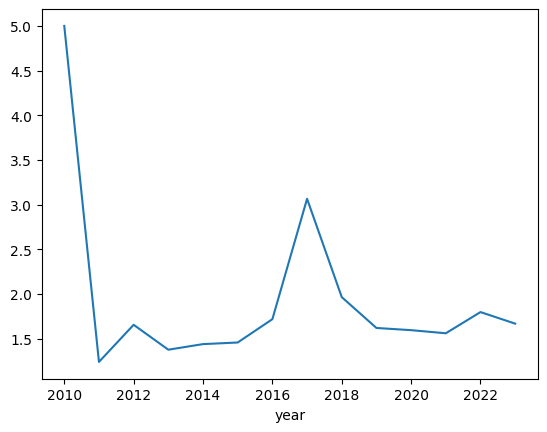

In [ ]:
df.groupby('year')['rating'].mean().plot(kind='line')
# kind: line, bar,

### Подготовить к выгрузке

- не забудьте вспомогательные столбцы, которые уже не нужны

- в идеале при выкладывании данных данные снабжаются паспортом (информацией, что лежит в каждом столбце по сути и по форме)

- не называйте файл так же, как назывался изначальный (если вам не хочется потерять оригинальные данные)

In [ ]:
df.to_csv('pandas_sem_2026.csv', index=False)

Вы великолепны.

(и готовы к половине НЭ по анализу данных на третьем курсе, состоящем из пандаса и базовой статистики)

## Частые проблемы

- Многие методы работают с датафреймами, а не сериями. Например, не стоит применять к частотной таблице стандартные методы, потому что она вообще-то столбец с индексами-категориями (но из неё можно сделать человеческий датафрейм тоже)
- Если хотите проверить, лежит ли в клетке NaN, используйте `if x is pd.NA` для конкретного значения и `df['col'].isna()` для фильтра
- Не копируйте датафреймы присваиванием (`df_1 = df` - это ПЛОХО), иначе значения могут меняться одновременно в двух датафреймах. Используйте `df.copy()`



### Тренажёры и доп. материалы
* [*100 заданий*](https://github.com/ajcr/100-pandas-puzzles)
* [*тетрадки по темам*](https://github.com/guipsamora/pandas_exercises)